# NN implementation of multi-input logic gates

### Truth table generation

In [1]:
import numpy as np
import itertools
import pandas as pd


def system1_binary_output(a, b, c):
    return int((a and (not b) and (not c)) or
               ((not a) and b and (not c)) or
               ((not a) and (not b) and c) or
               (a and b and c))

def system2_binary_output(a, b, c, d):
    return int((a and b and c) or
               (a and b and d) or
               (a and c and d) or
               (b and c and d))

# -----------------------------
# Truth table generators
# -----------------------------
def generate_truth_table_system1():
    rows = []
    for a, b, c in itertools.product([0, 1], repeat=3):
        y = system1_binary_output(a, b, c)
        rows.append([a, b, c, y])
    return pd.DataFrame(rows, columns=["A", "B", "C", "out"])

def generate_truth_table_system2():
    rows = []
    for a, b, c, d in itertools.product([0, 1], repeat=4):
        y = system2_binary_output(a, b, c, d)
        rows.append([a, b, c, d, y])
    return pd.DataFrame(rows, columns=["A", "B", "C", "D", "out"])

def binary_to_bipolar(df):
    df_bipolar = df.copy()
    for col in df.columns:
        df_bipolar[col] = df[col].apply(lambda x: 1 if x == 1 else -1)
    return df_bipolar

# Generate tables
tt1_bin = generate_truth_table_system1()
tt2_bin = generate_truth_table_system2()

tt1_bip = binary_to_bipolar(tt1_bin)
tt2_bip = binary_to_bipolar(tt2_bin)

print("System 1 - Binary Truth Table")
display(tt1_bin)

print("System 1 - Bipolar Truth Table")
display(tt1_bip)

print("System 2 - Binary Truth Table")
display(tt2_bin)

print("System 2 - Bipolar Truth Table")
display(tt2_bip)


System 1 - Binary Truth Table


,A,B,C,out
0,0,0,0,0
1,0,0,1,1
2,0,1,0,1
3,0,1,1,0
4,1,0,0,1
5,1,0,1,0
6,1,1,0,0
7,1,1,1,1


System 1 - Bipolar Truth Table


,A,B,C,out
0,-1,-1,-1,-1
1,-1,-1,1,1
2,-1,1,-1,1
3,-1,1,1,-1
4,1,-1,-1,1
5,1,-1,1,-1
6,1,1,-1,-1
7,1,1,1,1


System 2 - Binary Truth Table


,A,B,C,D,out
0,0,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,1,0
4,0,1,0,0,0
5,0,1,0,1,0
6,0,1,1,0,0
7,0,1,1,1,1
8,1,0,0,0,0
9,1,0,0,1,0


System 2 - Bipolar Truth Table


,A,B,C,D,out
0,-1,-1,-1,-1,-1
1,-1,-1,-1,1,-1
2,-1,-1,1,-1,-1
3,-1,-1,1,1,-1
4,-1,1,-1,-1,-1
5,-1,1,-1,1,-1
6,-1,1,1,-1,-1
7,-1,1,1,1,1
8,1,-1,-1,-1,-1
9,1,-1,-1,1,-1


### Delta rule implementation (from scratch)

In [2]:
import numpy as np

class SingleNeuronDelta:
    def __init__(self, n_inputs, representation="binary", lr=0.3, seed=0):
        """
        representation = 'binary'  -> sigmoid output in [0, 1]
        representation = 'bipolar' -> bipolar sigmoid output in [-1, 1]
        """
        self.n_inputs = n_inputs
        self.representation = representation
        self.lr = lr
        
        rng = np.random.default_rng(seed)
        self.w = rng.uniform(-0.5, 0.5, size=n_inputs)
        self.b = rng.uniform(-0.5, 0.5)

    def activation(self, y_in):
        if self.representation == "binary":
            # Binary sigmoid
            return 1.0 / (1.0 + np.exp(-y_in))
        elif self.representation == "bipolar":
            # Bipolar sigmoid
            return 2.0 / (1.0 + np.exp(-y_in)) - 1.0
        else:
            raise ValueError("representation must be 'binary' or 'bipolar'")

    def activation_derivative_from_output(self, y):
        if self.representation == "binary":
            # If y = sigmoid(y_in), derivative = y(1-y)
            return y * (1.0 - y)
        elif self.representation == "bipolar":
            # If y = 2/(1+e^-y_in)-1, derivative = 0.5*(1-y^2)
            return 0.5 * (1.0 - y**2)

    def predict_raw(self, X):
        y_in = X @ self.w + self.b
        return self.activation(y_in)

    def predict(self, X):
        y = self.predict_raw(X)
        if self.representation == "binary":
            return (y >= 0.5).astype(int)
        else:
            return np.where(y >= 0, 1, -1)

    def accuracy(self, X, T):
        pred = self.predict(X)
        return np.mean(pred == T)

    def train(self, X, T, max_epochs=10000, verbose=False):
        history = {
            "sse": [],
            "accuracy": []
        }
        first_perfect_epoch = None

        for epoch in range(max_epochs):
            sse = 0.0

            # Online Delta rule
            for x, t in zip(X, T):
                y_in = np.dot(self.w, x) + self.b
                y = self.activation(y_in)
                error = t - y
                deriv = self.activation_derivative_from_output(y)

                # Delta update
                self.w += self.lr * error * deriv * x
                self.b += self.lr * error * deriv

                sse += 0.5 * (error ** 2)

            acc = self.accuracy(X, T)
            history["sse"].append(sse)
            history["accuracy"].append(acc)

            if first_perfect_epoch is None and acc == 1.0:
                first_perfect_epoch = epoch + 1

            if verbose and ((epoch + 1) % 500 == 0 or epoch == 0):
                print(f"Epoch {epoch+1:5d} | SSE = {sse:.6f} | Accuracy = {acc*100:.2f}%")

        return history, first_perfect_epoch


### Data preparation, training, and results

,System,Representation,Final Accuracy (%),First Perfect Epoch
0,System 1,binary,50.0,NaN
1,System 1,bipolar,50.0,NaN
2,System 2,binary,100.0,11.0
3,System 2,bipolar,100.0,1.0


System 1 | BINARY
Final Accuracy: 50.00%
First Perfect Epoch: None
Weights: [0.06946575 0.03358971 0.00037674]
Bias: -0.048715
Predictions: [0 0 0 0 1 1 1 1]

System 1 | BIPOLAR
Final Accuracy: 50.00%
First Perfect Epoch: None
Weights: [-0.06867263  0.01215204  0.01215204]
Bias: -0.000000
Predictions: [ 1  1  1  1 -1 -1 -1 -1]

System 2 | BINARY
Final Accuracy: 100.00%
First Perfect Epoch: 11
Weights: [7.66401637 7.66388669 7.66389607 7.66390462]
Bias: -19.200132
Predictions: [0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1]

System 2 | BIPOLAR
Final Accuracy: 100.00%
First Perfect Epoch: 1
Weights: [5.37611461 5.37613994 5.37613488 5.37612981]
Bias: -5.376029
Predictions: [-1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1  1  1]



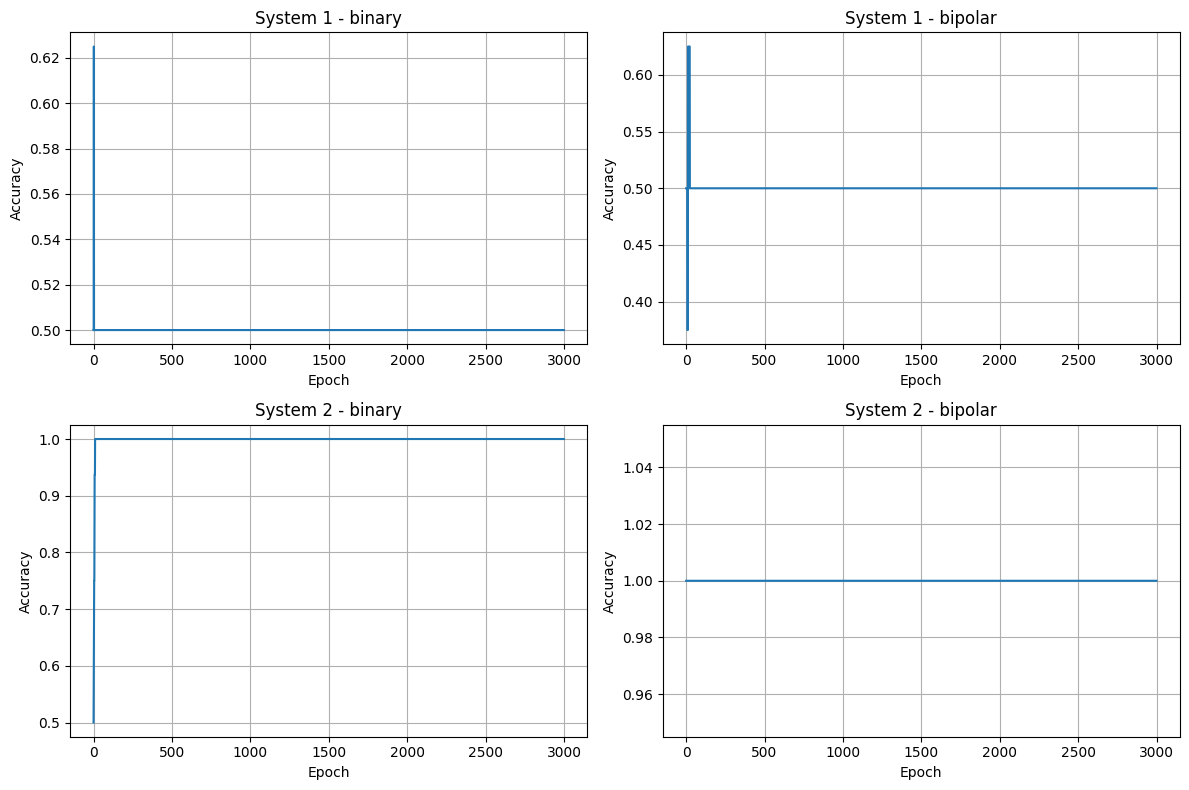

In [3]:
import matplotlib.pyplot as plt

# -----------------------------
# Convert DataFrames to arrays
# -----------------------------
def prepare_dataset(df, representation="binary"):
    X = df.iloc[:, :-1].values.astype(float)
    T = df.iloc[:, -1].values.astype(float)
    return X, T

# Binary datasets
X1_bin, T1_bin = prepare_dataset(tt1_bin, "binary")
X2_bin, T2_bin = prepare_dataset(tt2_bin, "binary")

# Bipolar datasets
X1_bip, T1_bip = prepare_dataset(tt1_bip, "bipolar")
X2_bip, T2_bip = prepare_dataset(tt2_bip, "bipolar")

# -----------------------------
# Experiments
# -----------------------------
experiments = [
    ("System 1", "binary",  X1_bin, T1_bin, 3, 0.5),
    ("System 1", "bipolar", X1_bip, T1_bip, 3, 0.3),
    ("System 2", "binary",  X2_bin, T2_bin, 4, 0.5),
    ("System 2", "bipolar", X2_bip, T2_bip, 4, 0.3),
]

results = []

for system_name, rep, X, T, n_inputs, lr in experiments:
    model = SingleNeuronDelta(n_inputs=n_inputs, representation=rep, lr=lr, seed=0)
    history, first_perfect_epoch = model.train(X, T, max_epochs=10000, verbose=False)

    final_acc = model.accuracy(X, T)
    preds = model.predict(X)

    results.append({
        "System": system_name,
        "Representation": rep,
        "Final Accuracy": final_acc,
        "First Perfect Epoch": first_perfect_epoch,
        "Final Weights": model.w.copy(),
        "Final Bias": model.b,
        "Predictions": preds
    })

# Show numeric results
results_df = pd.DataFrame([{
    "System": r["System"],
    "Representation": r["Representation"],
    "Final Accuracy (%)": round(r["Final Accuracy"] * 100, 2),
    "First Perfect Epoch": r["First Perfect Epoch"]
} for r in results])

display(results_df)

# -----------------------------
# Print detailed predictions
# -----------------------------
for r in results:
    print("=" * 70)
    print(f"{r['System']} | {r['Representation'].upper()}")
    print(f"Final Accuracy: {r['Final Accuracy']*100:.2f}%")
    print(f"First Perfect Epoch: {r['First Perfect Epoch']}")
    print(f"Weights: {r['Final Weights']}")
    print(f"Bias: {r['Final Bias']:.6f}")
    print(f"Predictions: {r['Predictions']}")
    print()

# -----------------------------
# Plot convergence curves
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (system_name, rep, X, T, n_inputs, lr) in enumerate(experiments):
    model = SingleNeuronDelta(n_inputs=n_inputs, representation=rep, lr=lr, seed=0)
    history, first_perfect_epoch = model.train(X, T, max_epochs=3000, verbose=False)

    axes[idx].plot(history["accuracy"])
    axes[idx].set_title(f"{system_name} - {rep}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("Accuracy")
    axes[idx].grid(True)

plt.tight_layout()
plt.show()
